# Soliton Energy and Hamiltonian Weight Testing

In [5]:
%matplotlib widget
%matplotlib inline
import pickle
import numpy as np
import matplotlib.pyplot as plt


In [9]:
from dataclasses import dataclass

@dataclass
class Result():
    n_integrals_m : list[int]
    n_integrals_e : list[int]
    n_integrals_h : list[int]
    weight_m : list[int]
    weight_e : list[int]
    weight_h : list[int]
    avg_mae : list[float]
    std_mae : list[float]
    avg_time : list[float]
    std_time : list[float]
    avg_max_err : list[float] #average between groups, of max within groups (groups = n_energy, where each seed is a different result)
    max_max_err : list[float] #max between groups
    std_max_err : list[float]

#Import pickled data object
def reconstruct (file: str):
    with open(file, 'rb') as f:
        soliton_raw = pickle.load(f) #this is a list of the dicts of the experimental results, see above experiments for keys

    n_integrals_m = []
    n_integrals_e = []
    n_integrals_h = []
    weight_m = []
    weight_e = []
    weight_h = []
    avg_mae = []
    std_mae = []
    avg_time = []
    std_time = []
    avg_max_err = [] #average between groups, of max within groups (groups = n_energy, where each seed is a different result)
    max_max_err = [] #max between groups
    std_max_err = []
    

    #Reconstructing usable experiment data
    print("Loaded Experiment Results:\n") #formatting
    for result in soliton_raw:
        n_integrals_m.append(result['n_integrals']['momentum'])
        n_integrals_e.append(result['n_integrals']['energy'])
        n_integrals_h.append(result['n_integrals']['hamiltonian'])
        weight_m.append(result['weights']['momentum'])
        weight_e.append(result['weights']['energy'])
        weight_h.append(result['weights']['hamiltonian'])
        avg_mae.append(result['mae_mean'])
        std_mae.append(result['mae_std'])
        avg_time.append(result['time_mean'])
        std_time.append(result['time_std'])
        avg_max_err.append(np.mean(result['raw_data']['max_error']))
        max_max_err.append(np.max(result['raw_data']['max_error']))
        std_max_err.append(np.std(result['raw_data']['max_error']))
        #printing out values
        print(f" Avg MAE: {result['mae_mean']:.6e} | Avg Time: {result['time_mean']:.2e}s | Avg Max Error: {np.mean(result['raw_data']['max_error']):.6e}")
        print(f"---------------| Std MAE: {result['mae_std']:.6e} | Std Time: {result['time_std']:.2e}s | Std Max Error: {np.std(result['raw_data']['max_error']):.6e}")

    result = Result(n_integrals_m, n_integrals_e, n_integrals_h,
                    weight_m, weight_e, weight_h,
                    avg_mae, std_mae, avg_time, 
                    std_time, avg_max_err, max_max_err, std_max_err)
    return result

def dual_weights_v_err(result):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    x = result.weight_e
    y = result.weight_h
    z = result.avg_mae
    ax.errorbar(x, y, z, zerr=result.std_mae, fmt='o', ecolor='red')
    return fig


In [7]:
result = reconstruct('1_soliton_energy_hamilt_weight_test')

Loaded Experiment Results:

 Avg MAE: 3.614470e-03 | Avg Time: 8.31e+01s | Avg Max Error: 7.916654e-02
---------------| Std MAE: 1.949885e-03 | Std Time: 1.97e+01s | Std Max Error: 4.282808e-02
 Avg MAE: 1.535299e-03 | Avg Time: 1.10e+02s | Avg Max Error: 1.348489e-02
---------------| Std MAE: 4.967042e-04 | Std Time: 2.62e+01s | Std Max Error: 5.515590e-03
 Avg MAE: 1.261564e-03 | Avg Time: 1.07e+02s | Avg Max Error: 9.849217e-03
---------------| Std MAE: 4.330457e-04 | Std Time: 2.74e+01s | Std Max Error: 4.400608e-03
 Avg MAE: 1.301484e-03 | Avg Time: 1.20e+02s | Avg Max Error: 1.116554e-02
---------------| Std MAE: 4.068139e-04 | Std Time: 2.67e+01s | Std Max Error: 4.904330e-03
 Avg MAE: 1.576456e-03 | Avg Time: 1.29e+02s | Avg Max Error: 1.431336e-02
---------------| Std MAE: 5.171010e-04 | Std Time: 2.95e+01s | Std Max Error: 5.110224e-03
 Avg MAE: 1.516469e-03 | Avg Time: 1.41e+02s | Avg Max Error: 1.572393e-02
---------------| Std MAE: 5.594881e-04 | Std Time: 4.81e+01s | Std 

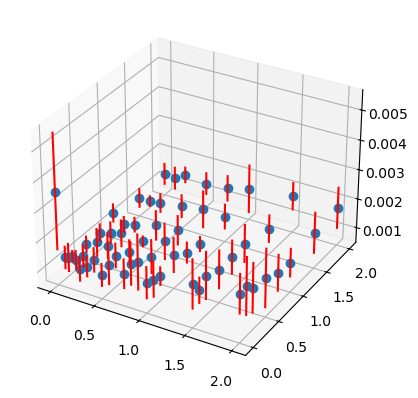

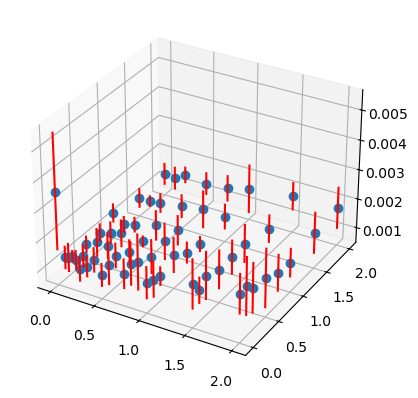

In [10]:
dual_weights_v_err(result)

In [11]:
np.argmin(result.avg_mae)

np.int64(16)

In [12]:
np.argmin(result.avg_max_err)

np.int64(24)

In [13]:
np.argmin(result.max_max_err)

np.int64(49)

In [14]:
print(f'Result: 16 | MAE: {result.avg_mae[16]} | AME: {result.avg_max_err[16]} | MME: {result.max_max_err[16]}')
print(f'---------- | STD of MAE: {result.std_mae[16]} | STD of ME {result.std_max_err[16]}')
print(f'Result: 24 | MAE: {result.avg_mae[24]} | AME: {result.avg_max_err[24]} | MME: {result.max_max_err[24]}')
print(f'---------- | STD of MAE: {result.std_mae[24]} | STD of ME {result.std_max_err[24]}')
print(f'Result: 49 | MAE: {result.avg_mae[49]} | AME: {result.avg_max_err[49]} | MME: {result.max_max_err[49]}')
print(f'---------- | STD of MAE: {result.std_mae[49]} | STD of ME {result.std_max_err[49]}')

Result: 16 | MAE: 0.0010511637820551792 | AME: 0.008518548682332039 | MME: 0.019008252769708633
---------- | STD of MAE: 0.0002185609391916374 | STD of ME 0.004059240737184513
Result: 24 | MAE: 0.001064719019147257 | AME: 0.008276342197010915 | MME: 0.015457435511052608
---------- | STD of MAE: 0.0003009402695412183 | STD of ME 0.003822257063926681
Result: 49 | MAE: 0.0011317912644396226 | AME: 0.010007236152887344 | MME: 0.015321338549256325
---------- | STD of MAE: 0.00020630330024735678 | STD of ME 0.003400169603547685


In [20]:
print(f'Weights of 24: ENERGY {result.weight_e[24]}  |  HAMILTONIAN {result.weight_h[24]}') #Best results

Weights of 24: ENERGY 0.0  |  HAMILTONIAN 0.5
